# 🌿 AgroDetect — Clasificador Agrícola con InceptionV3
**Grupo 9 | Curso: Computación Blanda / Visión por Computador**

Este notebook entrena un modelo InceptionV3 preentrenado en ImageNet con fine-tuning
para detectar enfermedades en plantas (Pepper Bell y Papa).

Compatible con:
- ✅ Google Colab (con GPU T4)
- ✅ Visual Studio Code / Jupyter local
- ✅ Jupyter Notebook standalone

---
**Dataset esperado:**
```
dataset/
  train/
    Pepper__bell__Bacterial_spot/
    Pepper__bell__healthy/
    Potato__Early_blight/
    Potato__Late_blight/
    Potato__healthy/
  validation/
    (mismas carpetas)
```

## 1️⃣ Detección de entorno y configuración inicial

In [1]:
import os
import sys

# ── Detectar si estamos en Colab ──────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
    print('🚀 Entorno detectado: Google Colab')
except ImportError:
    IN_COLAB = False
    print('💻 Entorno detectado: Local (VS Code / Jupyter)')

# ── Verificar GPU ─────────────────────────────────────────────────────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU disponible: {gpus[0].name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('⚠️  Sin GPU — se usará CPU (más lento)')

print(f'TensorFlow: {tf.__version__}')

💻 Entorno detectado: Local (VS Code / Jupyter)
⚠️  Sin GPU — se usará CPU (más lento)
TensorFlow: 2.21.0


## 2️⃣ Carga del dataset

> **En Colab:** Sube el ZIP del dataset o monta Google Drive
> **En local:** Asegúrate de que la carpeta `dataset/` esté en el mismo directorio que este notebook

In [2]:
# ── Configuración de rutas según entorno ─────────────────────────────────
if IN_COLAB:
    # Opción A: Montar Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    
    # ⚠️ CAMBIA esta ruta a donde tienes tu dataset en Drive:
    DATASET_BASE = '/content/drive/MyDrive/dataset'
    
    # Opción B: Subir ZIP directamente (descomenta si prefieres esto)
    # from google.colab import files
    # uploaded = files.upload()  # sube dataset.zip
    # !unzip -q dataset.zip -d /content/dataset
    # DATASET_BASE = '/content/dataset'
else:
    # Local: carpeta dataset/ junto al notebook
    DATASET_BASE = os.path.join(os.getcwd(), 'dataset')

TRAIN_DIR = os.path.join(DATASET_BASE, 'train')
VAL_DIR   = os.path.join(DATASET_BASE, 'validation')

# Verificar que existen
for d, label in [(TRAIN_DIR, 'train'), (VAL_DIR, 'validation')]:
    if os.path.isdir(d):
        clases = os.listdir(d)
        print(f'✅ {label}: {len(clases)} clases → {clases}')
    else:
        print(f'❌ No encontrado: {d}')
        print('   Por favor ajusta la variable DATASET_BASE')

✅ train: 5 clases → ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']
✅ validation: 5 clases → ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


## 3️⃣ Hiperparámetros y configuración del modelo

In [3]:
# ── Hiperparámetros optimizados para velocidad + accuracy ─────────────────
IMG_SIZE    = (224, 224)   # InceptionV3 soporta desde 75x75; usamos 224 para equilibrio
BATCH_SIZE  = 32           # 32 es óptimo para GPU T4 / GPU local 4-8 GB
EPOCHS_FASE1 = 5           # Fase 1: solo cabecera (rápido)
EPOCHS_FASE2 = 5           # Fase 2: fine-tuning últimas capas
LR_FASE1    = 1e-3
LR_FASE2    = 1e-4
MODEL_PATH  = 'agrodetect_inceptionv3.keras'

print('Configuración:')
print(f'  Imagen:     {IMG_SIZE}')
print(f'  Batch:      {BATCH_SIZE}')
print(f'  Épocas F1:  {EPOCHS_FASE1}')
print(f'  Épocas F2:  {EPOCHS_FASE2}')
print(f'  Guardado:   {MODEL_PATH}')

Configuración:
  Imagen:     (224, 224)
  Batch:      32
  Épocas F1:  5
  Épocas F2:  5
  Guardado:   agrodetect_inceptionv3.keras


## 4️⃣ Generadores de datos con Augmentation

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Preprocesamiento InceptionV3 (escala [-1, 1]) ─────────────────────────
from tensorflow.keras.applications.inception_v3 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nClases ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Imágenes train:      {train_gen.samples}')
print(f'Imágenes validation: {val_gen.samples}')

# Guardar mapeo de clases para la app
import json
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print('\n✅ class_names.json guardado')

Found 2152 images belonging to 5 classes.
Found 2152 images belonging to 5 classes.

Clases (5): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Imágenes train:      2152
Imágenes validation: 2152

✅ class_names.json guardado


## 5️⃣ Visualización de imágenes del dataset

Found 2152 images belonging to 5 classes.


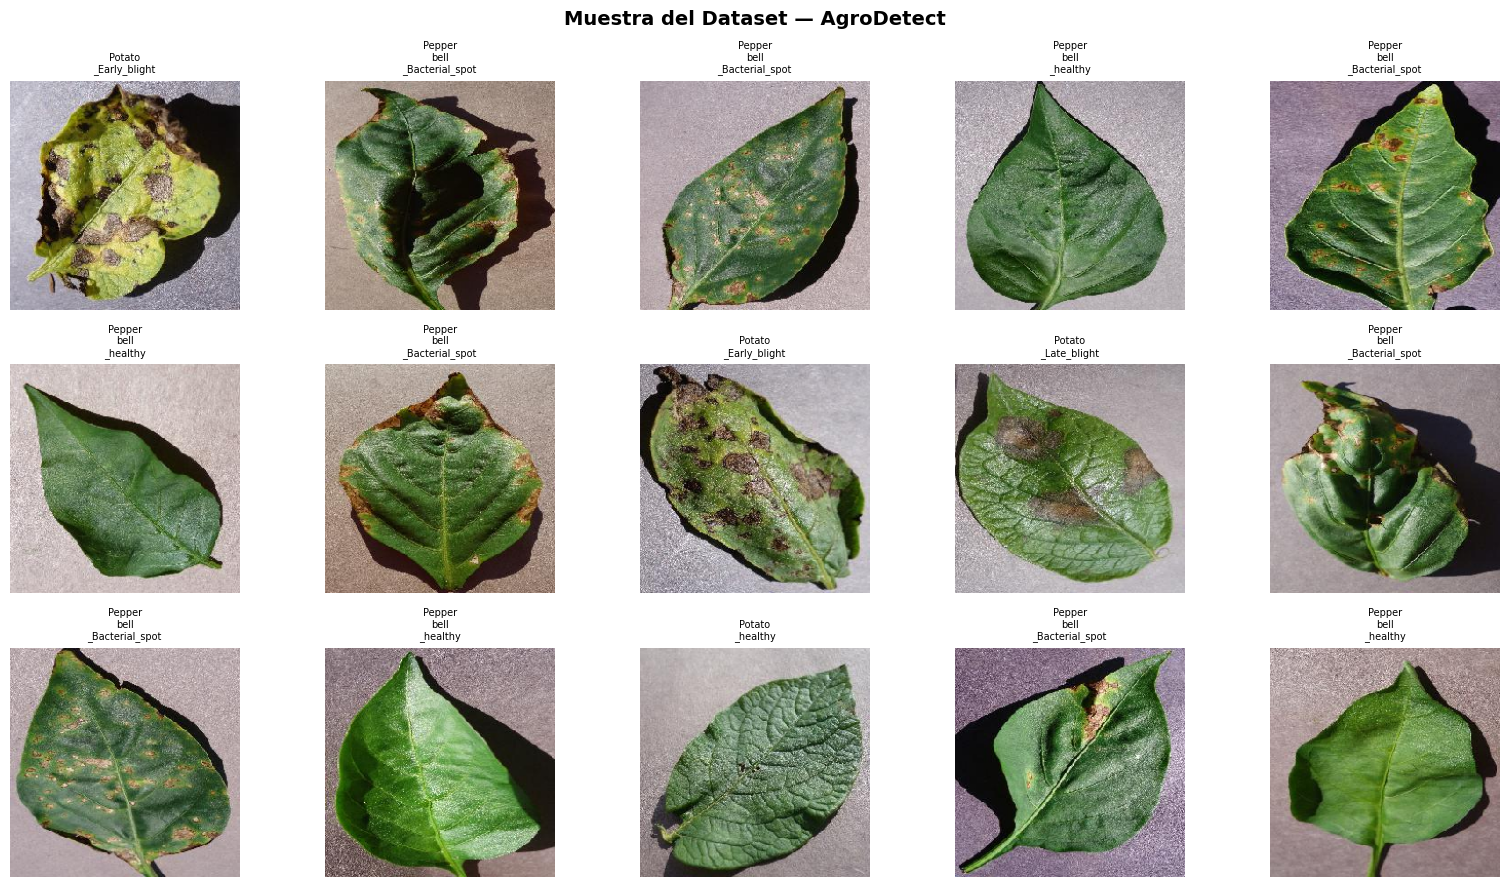

✅ dataset_sample.png guardado


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Ver muestra del dataset SIN preprocesamiento
raw_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=15, class_mode='categorical', shuffle=True
)

imgs, labels = next(raw_gen)
idx_to_class = {v: k for k, v in raw_gen.class_indices.items()}

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
fig.suptitle('Muestra del Dataset — AgroDetect', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    clase = idx_to_class[np.argmax(labels[i])]
    ax.set_title(clase.replace('__', '\n'), fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('dataset_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ dataset_sample.png guardado')

## 6️⃣ Construcción del modelo — Transfer Learning con InceptionV3

In [6]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers

# ── BASE: InceptionV3 sin cabecera, pesos ImageNet ───────────────────────
base_model = InceptionV3(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,          # Sin la capa de clasificación ImageNet
    weights='imagenet'
)
base_model.trainable = False    # Congelar durante fase 1

# ── CABECERA personalizada ────────────────────────────────────────────────
inputs  = base_model.input
x       = base_model.output
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='AgroDetect_InceptionV3')

# Resumen compacto
print(f'Parámetros totales:     {model.count_params():,}')
print(f'Parámetros entrenables: {sum(p.numpy().size for p in model.trainable_weights):,}')
print(f'Parámetros congelados:  {sum(p.numpy().size for p in model.non_trainable_weights):,}')

Parámetros totales:     22,336,805
Parámetros entrenables: 529,925
Parámetros congelados:  21,806,880


## 7️⃣ Fase 1 — Entrenamiento de la cabecera (base congelada)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(
    optimizer=optimizers.Adam(LR_FASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_f1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
]

print('🔵 FASE 1: Entrenando cabecera (base congelada)...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FASE1,
    callbacks=callbacks_f1,
    verbose=1
)
print(f'\n✅ Fase 1 completada — Val Accuracy: {max(history1.history["val_accuracy"]):.4f}')

🔵 FASE 1: Entrenando cabecera (base congelada)...
Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.7960 - loss: 0.7156 - val_accuracy: 0.8736 - val_loss: 0.3506 - learning_rate: 0.0010
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8810 - loss: 0.3940 - val_accuracy: 0.9117 - val_loss: 0.2420 - learning_rate: 0.0010
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8764 - loss: 0.3818 - val_accuracy: 0.9261 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9071 - loss: 0.3175 - val_accuracy: 0.9442 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9103 - loss: 0.2912 - val_accuracy: 0.9526 - val_loss: 0.1342 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✅ Fase 1 completada — Val Accuracy: 0.9526


## 8️⃣ Fase 2 — Fine-Tuning (descongelar últimas capas)

In [8]:
# Descongelar desde la capa 249 en adelante (últimos 2 módulos Inception)
base_model.trainable = True
FINE_TUNE_AT = 249

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas en base: {trainable_count}')

model.compile(
    optimizer=optimizers.Adam(LR_FASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_f2 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('\n🟢 FASE 2: Fine-tuning (últimas capas descongeladas)...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FASE2,
    callbacks=callbacks_f2,
    verbose=1
)
print(f'\n✅ Fase 2 completada — Val Accuracy: {max(history2.history["val_accuracy"]):.4f}')
print(f'💾 Modelo guardado en: {MODEL_PATH}')

Capas descongeladas en base: 62

🟢 FASE 2: Fine-tuning (últimas capas descongeladas)...
Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8701 - loss: 0.4820
Epoch 1: val_accuracy improved from None to 0.95028, saving model to agrodetect_inceptionv3.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.8875 - loss: 0.4313 - val_accuracy: 0.9503 - val_loss: 0.1555 - learning_rate: 1.0000e-04
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9333 - loss: 0.2233
Epoch 2: val_accuracy improved from 0.95028 to 0.96654, saving model to agrodetect_inceptionv3.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9345 - loss: 0.2138 - val_accuracy: 0.9665 - val_loss: 0.1260 - learning_rate: 1.0000e-04
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9404 - loss: 0.1727
Epoch 3: val_accuracy improved from 0.96654 to 0.97258, saving model to agrodetect_inceptionv3.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9503 - loss: 0.1468 - va

## 9️⃣ Visualización de resultados de entrenamiento

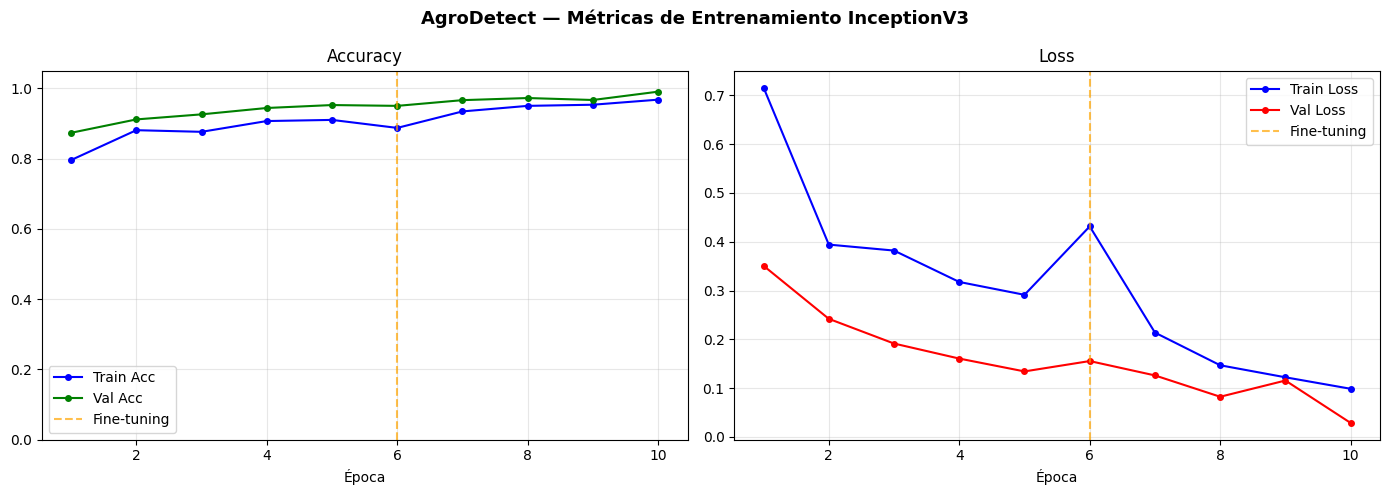

✅ training_curves.png guardado


In [9]:
# Combinar historiales de ambas fases
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist = combine_history(history1, history2)
epochs_total = range(1, len(hist['accuracy']) + 1)
fase2_start  = len(history1.history['accuracy']) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AgroDetect — Métricas de Entrenamiento InceptionV3', fontsize=13, fontweight='bold')

# Accuracy
ax1.plot(epochs_total, hist['accuracy'],     'b-o', markersize=4, label='Train Acc')
ax1.plot(epochs_total, hist['val_accuracy'], 'g-o', markersize=4, label='Val Acc')
ax1.axvline(x=fase2_start, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning')
ax1.set_title('Accuracy'); ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Loss
ax2.plot(epochs_total, hist['loss'],     'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_total, hist['val_loss'], 'r-o', markersize=4, label='Val Loss')
ax2.axvline(x=fase2_start, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning')
ax2.set_title('Loss'); ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ training_curves.png guardado')

## 🔟 Evaluación final con Matriz de Confusión

68/68 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step

📊 Reporte de Clasificación:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.99      0.99      0.99       500
       Pepper__bell___healthy       0.99      0.99      0.99       500
        Potato___Early_blight       1.00      0.99      0.99       500
         Potato___Late_blight       0.98      1.00      0.99       500
             Potato___healthy       0.99      0.96      0.97       152

                     accuracy                           0.99      2152
                    macro avg       0.99      0.99      0.99      2152
                 weighted avg       0.99      0.99      0.99      2152



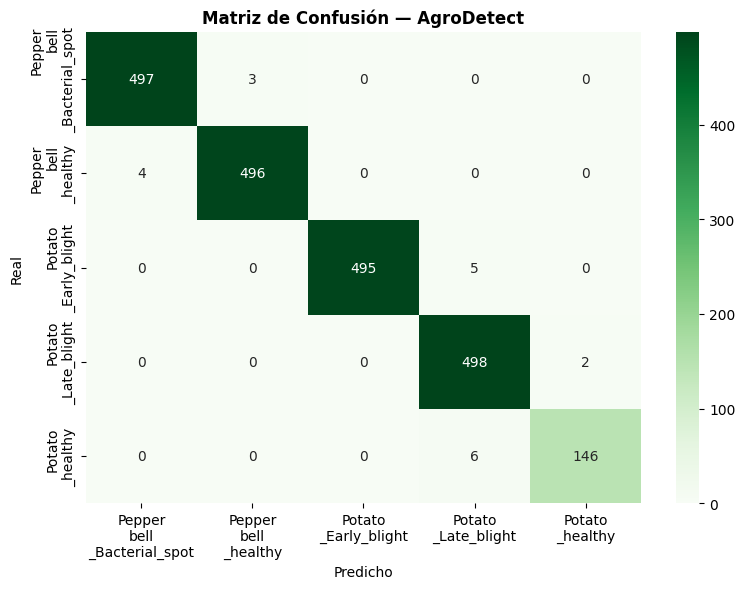

✅ confusion_matrix.png guardado


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones sobre validación
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# Reporte
print('\n📊 Reporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[c.replace('__', '\n') for c in CLASS_NAMES],
            yticklabels=[c.replace('__', '\n') for c in CLASS_NAMES],
            ax=ax)
ax.set_title('Matriz de Confusión — AgroDetect', fontsize=12, fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix.png guardado')

## 1️⃣1️⃣ Prueba de inferencia sobre imágenes individuales

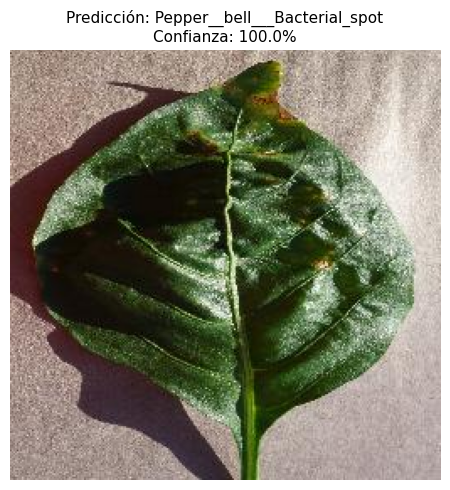


Resultado: Pepper__bell___Bacterial_spot (100.0%)


In [11]:
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def predict_image(img_path, model, class_names, img_size=(224, 224)):
    """Predice la clase de una imagen y muestra el resultado."""
    img = keras_image.load_img(img_path, target_size=img_size)
    arr = keras_image.img_to_array(img)
    arr = preprocess_input(np.expand_dims(arr, 0))
    
    preds   = model.predict(arr, verbose=0)[0]
    idx     = np.argmax(preds)
    clase   = class_names[idx]
    confianza = preds[idx] * 100
    
    # Mostrar imagen
    plt.figure(figsize=(5, 5))
    plt.imshow(keras_image.load_img(img_path))
    plt.title(f'Predicción: {clase}\nConfianza: {confianza:.1f}%', fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return clase, confianza

# Probar con una imagen del set de validación
primera_clase = CLASS_NAMES[0]
dir_clase = os.path.join(VAL_DIR, primera_clase)
img_ejemplo = os.path.join(dir_clase, os.listdir(dir_clase)[0])

clase, conf = predict_image(img_ejemplo, model, CLASS_NAMES)
print(f'\nResultado: {clase} ({conf:.1f}%)')

## 1️⃣2️⃣ Guardar artefactos finales

In [12]:
import json

# Accuracy final
loss, acc = model.evaluate(val_gen, verbose=0)
print(f'\n📈 Accuracy final en validación: {acc*100:.2f}%')
print(f'   Loss final:                   {loss:.4f}')

# Guardar métricas
metricas = {
    'model': 'InceptionV3',
    'val_accuracy': float(acc),
    'val_loss': float(loss),
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'img_size': list(IMG_SIZE),
    'epochs_fase1': EPOCHS_FASE1,
    'epochs_fase2': EPOCHS_FASE2,
    'fine_tune_at_layer': FINE_TUNE_AT,
    'total_params': model.count_params()
}

with open('model_metrics.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print('\n📁 Archivos generados:')
archivos = ['agrodetect_inceptionv3.keras', 'class_names.json',
            'model_metrics.json', 'training_curves.png',
            'confusion_matrix.png', 'dataset_sample.png']
for f in archivos:
    existe = '✅' if os.path.exists(f) else '❌'
    print(f'  {existe} {f}')

# En Colab: copiar a Drive
if IN_COLAB:
    import shutil
    drive_output = '/content/drive/MyDrive/AgroDetect_outputs'
    os.makedirs(drive_output, exist_ok=True)
    for f in archivos:
        if os.path.exists(f):
            shutil.copy(f, drive_output)
    print(f'\n☁️  Archivos copiados a Drive: {drive_output}')


📈 Accuracy final en validación: 99.07%
   Loss final:                   0.0287

📁 Archivos generados:
  ✅ agrodetect_inceptionv3.keras
  ✅ class_names.json
  ✅ model_metrics.json
  ✅ training_curves.png
  ✅ confusion_matrix.png
  ✅ dataset_sample.png


---
## ✅ Resumen del Entrenamiento

| Componente | Valor |
|---|---|
| Modelo base | InceptionV3 (ImageNet) |
| Estrategia | Transfer Learning + Fine-tuning |
| Optimizador | Adam |
| Fase 1 LR | 1e-3 (cabecera) |
| Fase 2 LR | 1e-4 (fine-tuning) |
| Regularización | Dropout 0.4 + BatchNorm |
| Callbacks | EarlyStopping, ReduceLR, ModelCheckpoint |

## 🚀 Siguiente paso
Ejecuta `streamlit run app_agrodetect.py` para lanzar la interfaz web.